<img src="../logo_UNSAM.jpg" align="right" width="150" /> 

# Análisis y Procesamiento de Señales
## Trabajo Semanal Nº 4: Primeras nociones de estimación espectral
**Autor:** Federico Pieri  
**Institución:** Escuela de Ciencia y Tecnología — Universidad Nacional de San Martín (UNSAM)

---

## Introducción

La herramienta fundamental para la estimación precisa de los parámetros de una señal (como su amplitud y frecuencia) a partir de un conjunto finito de muestras es la Transformada Discreta de Fourier (DFT). Sin embargo, la DFT asume implícitamente que la señal analizada es periódica dentro de la ventana de observación.

Cuando la frecuencia real de la señal no coincide exactamente con uno de los puntos discretos de análisis de la DFT (*bin*), se produce una discontinuidad en los bordes del bloque de tiempo. En el dominio frecuencial, esto se manifiesta como **desparramo espectral** (*spectral leakage*, fenómeno que caracterizamos en el trabajo anterior), donde la energía de la señal se esparce hacia otras frecuencias. Simultáneamente, si el pico de la señal cae entre dos bines, el valor que medimos en el bin más cercano sufre una caída de ganancia.

Para mitigar estos efectos, se recurre a la técnica de **ventaneo** (*windowing*). Matemáticamente, multiplicar la señal por una ventana no rectangular en el tiempo equivale a convolucionar su espectro con la respuesta en frecuencia de la ventana.

### Objetivo del Experimento

En este trabajo evaluaremos el desempeño de los estimadores de amplitud $\hat{a}_1$ y frecuencia $\hat{\Omega}_1$, definidos de la siguiente manera:

Estimador de amplitud:
$$\hat{a}_1^{(i)}=|X_w^{(i)}(\Omega_0)|=|\mathcal{F}\{x(n)\cdot w_i(n)\}|$$

Estimador de frecuencia:
$$\hat{\Omega}_1^{(i)}=\arg\max_{\Omega}\{|X_w^{(i)}(\Omega)|\}$$

El análisis se realizará mediante el cálculo del sesgo y la varianza de estos estimadores para una señal senoidal contaminada con Ruido Blanco Gaussiano Aditivo. La señal general se define como:

$$x(n)=a_0\cdot\sin(\Omega_1\cdot n)+n_a(n)$$

Donde la frecuencia presenta una desintonía aleatoria dada por $f_r\sim\mathcal{U}(-2,2)$, lo que provocará que el tono fluctúe alrededor de la frecuencia central $\Omega_0=\frac{\pi}{2}$.

Implementaremos una simulación con $M=200$ realizaciones para dos relaciones señal ruido diferentes ($\text{SNR}$ de $3\text{ dB}$ y $10\text{ dB}$). A través del cálculo del **sesgo** ($s$) y la **varianza** ($v$) empírica, analizaremos y compararemos el comportamiento de cuatro ventanas: Rectangular (sin ventana), Flat-top, Blackman-Harris y Hann.

---

## 1. Generación de la señal

En el siguiente bloque de código se genera la matriz de señales de tamaño $N \times M$ con la que se realizarán las pruebas de la simulación.

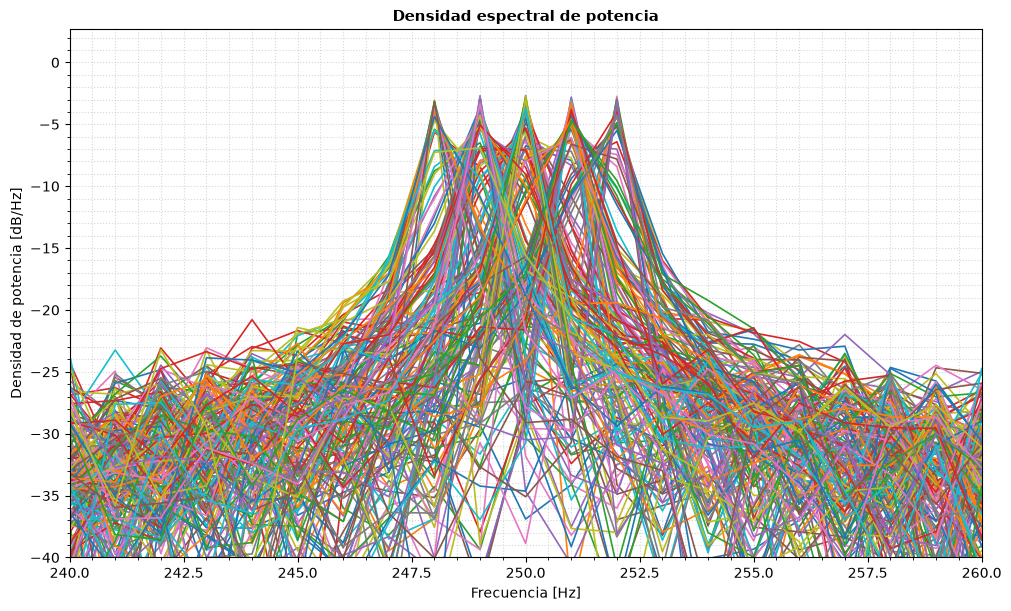

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
from IPython.display import display, HTML

display(HTML("""
<style>
/* Centrado para JupyterLab y Jupyter Notebook 7+ */
.jp-RenderedImage {
    display: flex;
    justify-content: center;
}
.jp-OutputArea-child {
    display: flex;
    justify-content: center;
}

/* Centrado para Jupyter Notebook Clásico (por si acaso) */
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
"""))
# -*- coding: utf-8 -*-
"""
Created on Sun Sep  6 10:22:10 2026

@author: Fede
"""
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as sp

#%% --------------------------------- Definiciones

fs = 1000
N = 1000
a = 2
v_max = np.sqrt(2)
M = 200
snrs = [3, 10]
bin_f0 = N//4
snr = 10
f0 = fs/4

ventanas = {
    'Rectangular': np.ones(N),
    'Flat-top': sp.flattop(N),
    'Blackman': sp.blackmanharris(N),
    'Hann': sp.hann(N)     # Otra ventana de scipy
}

resultados = {snr: {name: {} for name in ventanas} for snr in snrs}

#%% ------------------------- Calculos para todas las ventanas y snrs

df = fs/N

tt=np.arange(0,N,1)
fr = np.random.uniform(-a,a,M)
f = (f0+fr*fs/N)
tt = tt.reshape(N, 1)
frec = np.arange(int(N / 2)) * (fs / N)

for snr in snrs:  
    xx = v_max * np.sin(2 * np.pi * f * tt / fs)
    pot = np.sqrt(10**(-snr/10))
    n_a = np.random.normal(0, pot, (N, M))
    xx = xx + n_a 
    for nombre_vent, ventana in ventanas.items():
        ventana_col = ventana.reshape(N, 1)
        x_v = xx * ventana_col
        X_V = np.fft.fft(x_v, axis=0)
        X_V = X_V[:(N//2),:]
        escala_amp = 2 / np.sum(ventana)
        
        X_V_pot = (np.abs(X_V/N)**2) /df 
        X_V_db = 10 * np.log10(X_V_pot)

        a_est = np.abs(X_V[bin_f0, :]) * escala_amp

        omega_est = np.argmax(np.abs(X_V), axis=0)

        resultados[snr][nombre_vent]['a_est'] = a_est
        resultados[snr][nombre_vent]['omega_est'] = omega_est
        resultados[snr][nombre_vent]['psd_db'] = X_V_db

#%% --------------------------------- ploteos psd

fig, ax = plt.subplots(1, 1, figsize=(10, 6),layout="constrained")

# --- Subplot 0: Espectro de Magnitud ---
ax.plot(frec,resultados[3]['Rectangular']['psd_db'], linewidth=1.2)
ax.set_xlim([240,260])
ax.set_ylim(-40)
ax.set_title("Densidad espectral de potencia", fontsize=11, fontweight='bold')
ax.set_ylabel("Densidad de potencia [dB/Hz]", fontsize=10)
ax.set_xlabel("Frecuencia [Hz]")
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.minorticks_on()



### Análisis del Espectro con Ventana Rectangular

En este gráfico de densidad espectral de potencia, que muestra las 200 realizaciones procesadas con ventana rectangular (implícita), podemos observar claramente cómo las señales son atenuadas por el propio efecto de la ventana.

El resultado que uno podría imaginarse idealmente para esta situación sería un tren de deltas de idéntica amplitud abarcando el rango de frecuencias desde $f_0 - 2\Delta f$ hasta $f_0 + 2\Delta f$, ya que la variación de frecuencia de la señal obedece a una distribución uniforme. 

Sin embargo, lo que realmente vemos es la consecuencia del producto de la señal por la ventana en el dominio del tiempo. Al pasar al dominio frecuencial, la DFT evalúa los lóbulos de la función $\text{sinc}$, provocando así una fuerte atenuación para aquellos valores de frecuencia reales que no caen exactamente sobre el centro de un *bin*.

---

## 2. Generación de histogramas y tablas de sesgo y varianza

A continuación, se grafican las estimaciones de amplitud y frecuencia calculadas previamente con el objetivo de visualizar la distribución estadística de dichas estimaciones en función de las distintas ventanas y relaciones señal a ruido (SNR) analizadas.

Además, se incluyen las tablas con el sesgo y la varianza calculados para cada estimador, lo que permite realizar una comparación del desempeño al aplicar las diferentes ventanas.


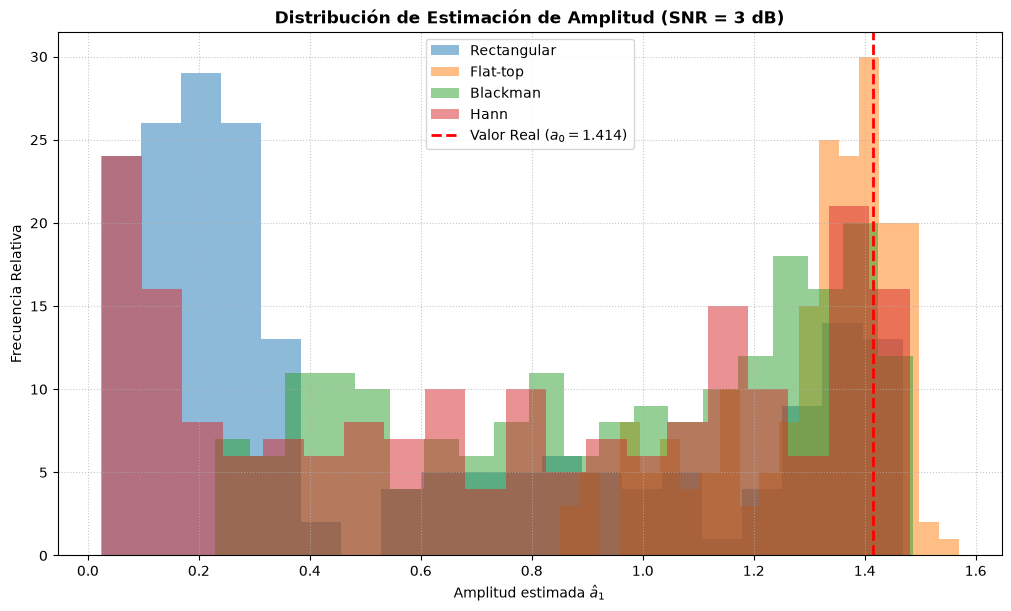

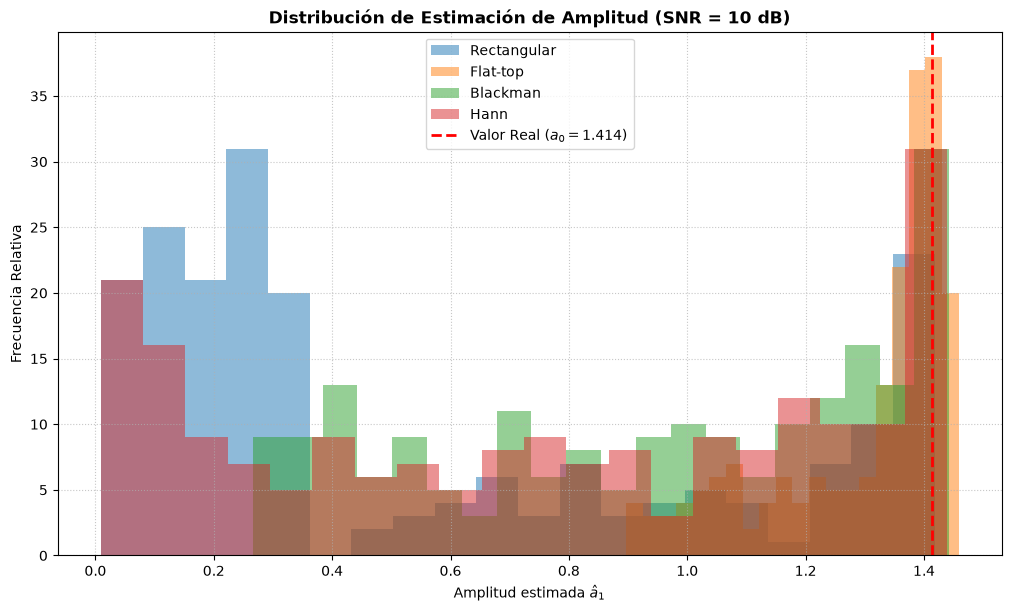

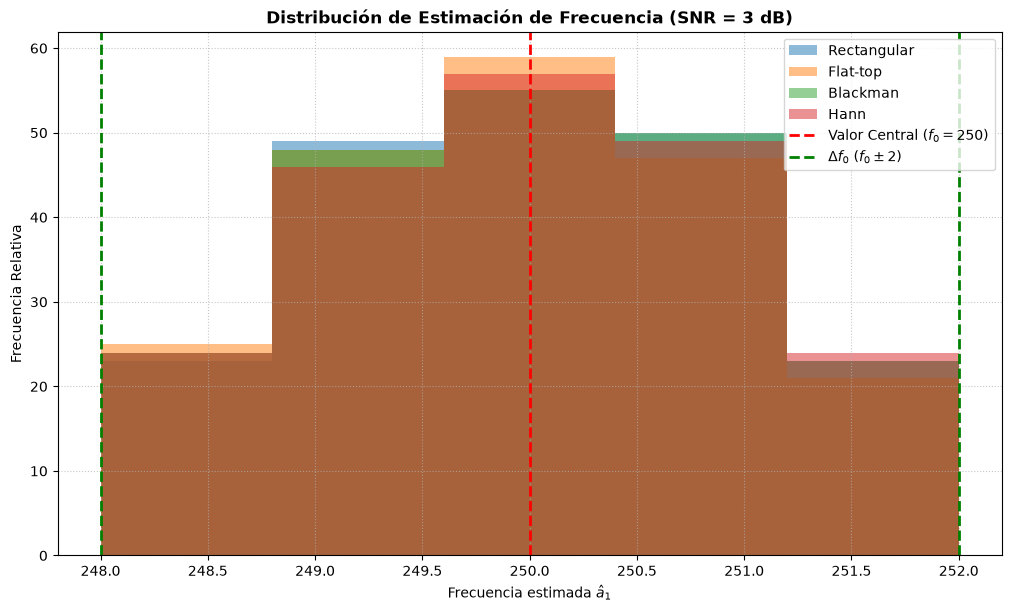

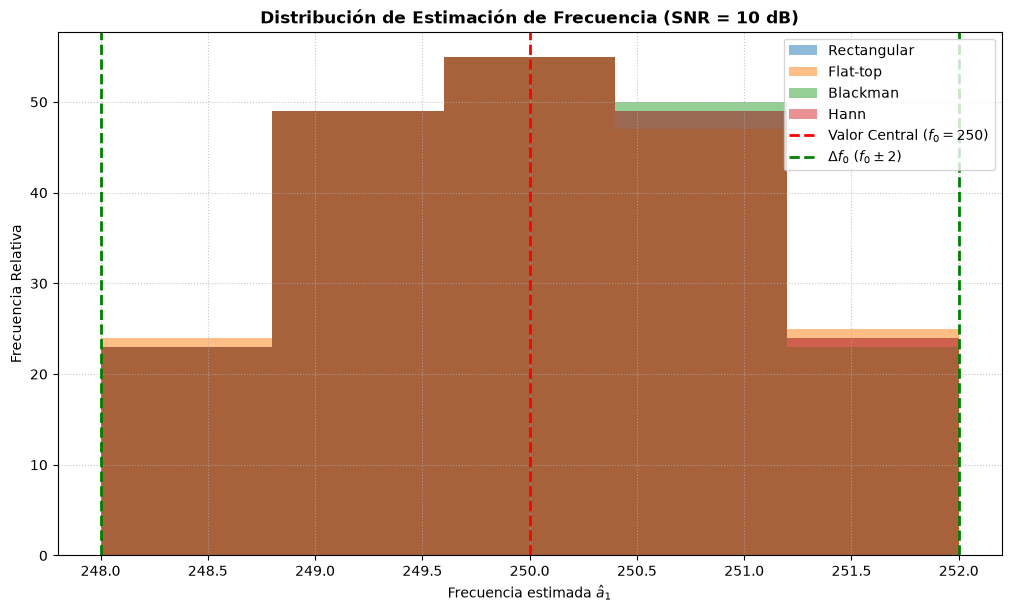

Ventana,Sesgo ($s_a$),Varianza ($v_a$)
Rectangular,-0.8625,2.3223e-01
Flat-top,-0.1146,2.6649e-02
Blackman,-0.4623,1.4238e-01
Hann,-0.6550,2.3758e-01


Ventana,Sesgo ($s_a$),Varianza ($v_a$)
Rectangular,-0.8640,2.3175e-01
Flat-top,-0.1150,2.2368e-02
Blackman,-0.4625,1.4030e-01
Hann,-0.6587,2.4152e-01


In [3]:
#%% -------------------------- Ploteo histogramas

for snr in snrs:
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    ax.set_title(f'Distribución de Estimación de Amplitud (SNR = {snr} dB)', fontsize=12, fontweight='bold')
    ax.set_xlabel(r'Amplitud estimada $\hat{a}_1$')
    ax.set_ylabel('Frecuencia Relativa')
    
    for nombre_vent in ventanas.keys():
        ax.hist(resultados[snr][nombre_vent]['a_est'], bins=20, alpha=0.5, label=nombre_vent)
        
    ax.axvline(v_max, color='red', linestyle='dashed', linewidth=2, label=f'Valor Real ($a_0={v_max:.3f}$)')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.show()

for snr in snrs:
    fig1, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    ax.set_title(f'Distribución de Estimación de Frecuencia (SNR = {snr} dB)', fontsize=12, fontweight='bold')
    ax.set_xlabel(r'Frecuencia estimada $\hat{a}_1$')
    ax.set_ylabel('Frecuencia Relativa')
    
    for nombre_vent in ventanas.keys():
        ax.hist(resultados[snr][nombre_vent]['omega_est'], bins=5, alpha=0.5, label=nombre_vent)
        
    ax.axvline(f0, color='red', linestyle='dashed', linewidth=2, label=f'Valor Central ($f_0={f0:.0f}$)')
    ax.axvline(f0 + 2, color='green', linestyle='dashed', linewidth=2, label=f'$\Delta f_0$ ($f_0 \pm 2$)')
    ax.axvline(f0 - 2, color='green', linestyle='dashed', linewidth=2)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.show()

def mostrar_tablas():
    for snr in snrs:
        # Definimos los estilos CSS para que la tabla quede prolija
        estilo_th = "border: 1px solid #dddddd; text-align: center; padding: 8px; background-color: #f2f2f2;"
        estilo_td = "border: 1px solid #dddddd; text-align: center; padding: 8px;"
        
        # Iniciamos el string HTML
        html = f"<h3 style='text-align: center;'>Resultados para SNR = {snr} dB</h3>"
        
        # --- 1. Tabla de Estimación de Amplitud ---
        html += "<h4 style='text-align: center; margin-bottom: 5px;'>Estimación de Amplitud</h4>"
        html += "<table style='margin: 0 auto; border-collapse: collapse; width: 70%; font-family: sans-serif;'>"
        html += f"<tr><th style='{estilo_th}'>Ventana</th><th style='{estilo_th}'>Sesgo ($s_a$)</th><th style='{estilo_th}'>Varianza ($v_a$)</th></tr>"
        
        for nombre_vent in ventanas.keys():
            a_est = resultados[snr][nombre_vent]['a_est']
            mu_a = np.mean(a_est)
            s_a =  mu_a - v_max
            v_a = np.mean((a_est - mu_a)**2)
            
            html += f"<tr><td style='{estilo_td}'><b>{nombre_vent}</b></td><td style='{estilo_td}'>{s_a:.4f}</td><td style='{estilo_td}'>{v_a:.4e}</td></tr>"
            
        html += "</table><br>"
        display(HTML(html))

mostrar_tablas()

---

## Análisis de los Histogramas

**Estimación de Frecuencia:**
En el histograma de frecuencia, la distribución aparenta tener un perfil gaussiano (con caídas en los extremos) en lugar de la distribución uniforme original. Este fenómeno es provocado por la discretización de la DFT: los *bins* centrales (249, 250 y 251 Hz) capturan todas las realizaciones que caen en un entorno de $\pm 0.5\text{ Hz}$ respecto a su centro. Sin embargo, debido al corte abrupto de la distribución de las señales simuladas, el *bin* de 252 Hz solo recibe muestras en el intervalo $[251.5, 252.0]\text{ Hz}$, y el de 248 Hz en el intervalo $[248.0, 248.5]\text{ Hz}$. Al abarcar un ancho efectivo que es exactamente la mitad, estos *bins* extremos acumulan la mitad de las ocurrencias, generando visualmente las "colas" de una campana.

**Estimación de Amplitud:**
El histograma de amplitudes refleja directamente el impacto de la pérdida por las atenuaciones de las ventanas. Esta dispersión en la medición evidencia la forma de las distintas ventanas atenúa las señales ante pequeñas desintonías. Es importante notar que, para desviaciones pequeñas como las de este experimento ($\pm 2\text{ Hz}$), la atenuación depende fundamentalmente del ancho y la planicidad del **lóbulo principal** de cada ventana, más que de sus lóbulos secundarios. Una transformada con un lóbulo angosto (como la función $\text{sinc}$ de la ventana Rectangular) atenúa en mayor manera la amplitud ante la menor desintonía, mientras que ventanas diseñadas con un lóbulo principal ancho (como la Flat-top) logran mantener la ganancia casi constante y agrupar las estimaciones en torno al valor real, siendo más inmunes a las fluctuaciones pequeñas.


---

## Conclusión

A partir de los resultados de sesgo ($s_a$) y varianza ($v_a$) expuestos en las tablas para ambas relaciones señal-ruido, podemos decir principalmente de cada ventana:

* La ventana Flat-top presenta, con amplia diferencia, el menor sesgo negativo en la estimación de amplitud, rondando los $-0.13$ en ambos escenarios de ruido. Su diseño de lóbulo principal ancho y plano permite que la ganancia se mantenga estable aunque la frecuencia real de la señal fluctúe hasta $\pm 2\text{ Hz}$ respecto al *bin* central.
* En el extremo opuesto, la ventana Rectangular muestra el peor desempeño con un sesgo mucho mayor cercano a $-0.93$. Su lóbulo principal extremadamente estrecho (función $\text{sinc}$) hace que cualquier desintonía aleatoria de la frecuencia corra la medición hacia la caída del lóbulo o los cruces por cero, subestimando la amplitud real. Las ventanas Blackman y Hann presentan sesgos intermedios ($-0.51$ y $-0.73$ respectivamente), acordes a la forma de sus lóbulos.

* Los valores de sesgo y varianza para cada ventana se mantienen virtualmente inalterados al pasar de una $\text{SNR}$ de $3\text{ dB}$ a $10\text{ dB}$. Esto confirma que, bajo los parámetros de esta simulación, la incertidumbre en la medición introducida por la fluctuación de la frecuencia ($f_r \sim \mathcal{U}(-2,2)$) enmascara por completo la contribución de la varianza producida por el ruido blanco gaussiano aditivo.

---

## Bonus

Analizamos el comportamiento del estimador de frecuencia al aplicarle la técnica de *zero padding* a nuestra señal.


In [5]:
import sys
from pathlib import Path
directorio_padre = str(Path.cwd().parent)
sys.path.insert(0, directorio_padre)
import gen_fun as gen

#%% ------------------------- Calculos para todas las ventanas y snrs

factor = 10
df = fs/N
SNR = 10
tt=np.arange(0,N,1)
fr = np.random.uniform(-a,a,M)
f = (f0+fr*fs/N)
tt = tt.reshape(N, 1)
frec = np.arange(int(N_1 / 2)) * (fs / N_1)

xx = v_max * np.sin(2 * np.pi * f * tt / fs)
pot = np.sqrt(10**(-snr/10))
n_a = np.random.normal(0, pot, (N, M))
xx = xx + n_a 

N_1 = N * factor

ventana = np.ones(N)
ventana_col = ventana.reshape(N, 1)
x_v = xx * ventana_col
X_V = np.fft.fft(x_v, axis=0,n = N_1)
X_V = X_V[:(N_1//2),:]
escala_amp = 2 / np.sum(ventana)
        
X_V_pot = (np.abs(X_V/N)**2) /df 
X_V_db = 10 * np.log10(X_V_pot)

df_1 = fs/N_1
omega_est = np.argmax(np.abs(X_V), axis=0) *df_1

#%% --------------------------------- ploteos psd

fig, ax = plt.subplots(1, 1, figsize=(10, 6),layout="constrained")

# --- Subplot 0: Espectro de Magnitud ---
ax.plot(frec,X_V_db, linewidth=1.2)
ax.set_xlim([240,260])
ax.set_ylim(-40)
ax.set_title("Densidad espectral de potencia", fontsize=11, fontweight='bold')
ax.set_ylabel("Densidad de potencia [dB/Hz]", fontsize=10)
ax.set_xlabel("Frecuencia [Hz]")
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.minorticks_on()

fig2, ax = plt.subplots(1, 1, figsize=(10, 6),layout="constrained")

# --- Subplot 0: Espectro de Magnitud ---
ax.plot(frec,X_V_db, linewidth=1.2)
ax.set_xlim([244,256])
ax.set_ylim(-20)
ax.set_title("Densidad espectral de potencia", fontsize=11, fontweight='bold')
ax.set_ylabel("Densidad de potencia [dB/Hz]", fontsize=10)
ax.set_xlabel("Frecuencia [Hz]")
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.minorticks_on()


fig1, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.set_title(f'Distribución de Estimación de Frecuencia (SNR = {snr} dB)', fontsize=12, fontweight='bold')
ax.set_xlabel(r'Frecuencia estimada $\hat{a}_1$')
ax.set_ylabel('Frecuencia Relativa')

ax.hist(omega_est, bins=20, alpha=0.5, label='Ventana rectangular')    
ax.axvline(f0, color='red', linestyle='dashed', linewidth=2, label=f'Valor Central ($f_0={f0:.0f}$)')
ax.axvline(f0 + 2, color='green', linestyle='dashed', linewidth=2, label=f'$\Delta f_0$ ($f_0 \pm 2$)')
ax.axvline(f0 - 2, color='green', linestyle='dashed', linewidth=2)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)
plt.show()


NameError: name 'N_1' is not defined

## Efecto del Zero Padding en la Estimación de Frecuencia

Al implementar la técnica de *Zero Padding* (evaluando la FFT sobre una longitud $N_{pad}$ diez veces mayor), se aumentó la densidad de puntos en el dominio frecuencial. La distancia entre *bins* consecutivos se redujo de $\Delta f = 1\text{ Hz}$ a un paso aparente de $\Delta f = 0.1\text{ Hz}$.

Como resultado, el estimador de frecuencia basado en el índice de máxima energía adquiere la capacidad de resolver variaciones decimales. El nuevo histograma demuestra cómo la distribución de la estimación $\hat{f}_1$ pierde el severo efecto de agrupamiento y el falso perfil gaussiano de los bordes. En su lugar, logra reconstruir mejor la forma plana y continua de la distribución aleatoria uniforme original inyectada en la señal, abarcando correctamente el intervalo continuo de $[248\text{ Hz}, 252\text{ Hz}]$. 

En todos los gráficos, los valores máximos de potencia se encuentran a aproximadamente -3 dB, ya que se representa un gráfico del espectro completo hasta Nyquist pero recortado a la mitad.